# Prophet Decomposition: April 2026 vs June 2026 Desktop World DAU

Compares the **rolled-up Mozaic-level Prophet model** for desktop legacy DAU between the
April 2026 cycle (forecast_start=2026-04-01) and the latest June 2026 cycle (forecast_start=2026-05-17).

The Mozaic class fits a single Prophet model on the world-rolled-up holiday-detrended DAU.
That model exposes:
- A **trend** (logistic growth, or linear depending on data shape).
- A **yearly** seasonality (Fourier basis).
- Two conditional weekly seasonalities: **weekly_historical** (training data before the recent window)
  and **weekly_recent** (the recent window + forecast horizon).

This notebook re-fits each Mozaic's Prophet model via its saved `forecast_model` factory function,
then overlays the trend, yearly, and weekly_recent components from April and June on three sets of axes.

The Mozaic dict stores `.trend` (a Series) directly, so we cross-check the re-fit by confirming
the re-fitted trend matches the stored trend.


In [1]:
# [setup]
import json
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.0f}".format)

REPO_ROOT = Path("/Users/brendanwells/work/mozaic-daily")

# Make mozaic_daily importable (not strictly needed here but consistent with other notebooks).
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

APRIL_DIR = REPO_ROOT / "data-official/2026-04/desktop_cps0.15983_thresh32_recent13_clip0.6"
JUNE_DIR  = REPO_ROOT / "data-official/2026-06/desktop_cps0.15983_thresh50_recent13_clip0.6"

APRIL_PKL = APRIL_DIR / "mozaic_objects.legacy_desktop.2026-04-01.pkl"
JUNE_PKL  = JUNE_DIR  / "mozaic_objects.legacy_desktop.2026-05-17.pkl"

print(f"April pkl exists: {APRIL_PKL.exists()}")
print(f"June  pkl exists: {JUNE_PKL.exists()}")
if not JUNE_PKL.exists():
    raise FileNotFoundError(
        f"June pkl missing at {JUNE_PKL}. Run scripts/run_main.py with "
        f"--data-sources legacy_desktop --metrics DAU --forecast-start-date 2026-05-17 "
        f"--output-dir {JUNE_DIR} to produce it."
    )

APRIL_PARAMS = json.loads((APRIL_DIR / "parameters.json").read_text())
JUNE_PARAMS  = json.loads((JUNE_DIR / "parameters.json").read_text())
print("\nApril parameters:")
print(json.dumps(APRIL_PARAMS, indent=2))
print("\nJune parameters:")
print(json.dumps(JUNE_PARAMS, indent=2))


April pkl exists: True
June  pkl exists: True

April parameters:
{
  "forecast_start_date": "2026-04-01",
  "desktop": {
    "prophet_changepoint_prior_scale": 0.15983,
    "prophet_changepoint_range": 0.7,
    "prophet_seasonality_prior_scale": 0.00825,
    "prophet_recent_weeks": 13,
    "holiday_threshold": -0.05,
    "holiday_max_radius": 5,
    "holiday_min_radius": 3,
    "holiday_effect_floor": -0.6
  }
}

June parameters:
{
  "platform": "legacy_desktop",
  "forecast_start_date": "2026-05-17",
  "prophet_recent_weeks": 13,
  "changepoint_prior_scale": 0.15983,
  "holiday_threshold": -0.05,
  "holiday_max_radius": 5,
  "holiday_min_radius": 3,
  "holiday_effect_floor": -0.6
}


In [2]:
# [load-mozaics]
# Each pkl is {metric: Mozaic}. We pull the DAU Mozaic from each.

with open(APRIL_PKL, "rb") as f:
    april_obj = pickle.load(f)
with open(JUNE_PKL, "rb") as f:
    june_obj = pickle.load(f)

apr_mz = april_obj["DAU"]
jun_mz = june_obj["DAU"]

print(f"April Mozaic: {len(apr_mz.tiles)} tiles, "
      f"historical {apr_mz.historical_dates.min().date()} \u2192 {apr_mz.historical_dates.max().date()}, "
      f"forecast {apr_mz.forecast_dates.min().date()} \u2192 {apr_mz.forecast_dates.max().date()}")
print(f"June  Mozaic: {len(jun_mz.tiles)} tiles, "
      f"historical {jun_mz.historical_dates.min().date()} \u2192 {jun_mz.historical_dates.max().date()}, "
      f"forecast {jun_mz.forecast_dates.min().date()} \u2192 {jun_mz.forecast_dates.max().date()}")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


April Mozaic: 45 tiles, historical 2020-01-01 → 2026-04-06, forecast 2026-04-01 → 2027-12-31
June  Mozaic: 45 tiles, historical 2020-01-01 → 2026-05-16, forecast 2026-05-17 → 2027-12-31


## Re-fit Prophet via the saved factory

The Mozaic pickle stores `forecast_model` as a *callable* (the model factory), not as a
fitted Prophet object. To inspect trend / yearly / weekly components, we have to re-run the
factory on each Mozaic's saved `holiday_detrended_historical_data` to produce a fitted Prophet
model.

This is deterministic (Prophet seeds with `np.random.seed(42)` inside the factory) so the
re-fit reproduces the original fit.


In [3]:
# [refit-prophet]
# Call each Mozaic's saved factory with that Mozaic's exact inputs and config.
# The factory returns (predictive_samples, fitted_prophet_model, prophet_forecast).
# We keep the fitted Prophet model `m` for decomposition.

def refit_world_prophet(mz, params: dict):
    """Re-fit the Mozaic-level Prophet model via the saved factory."""
    cps = params.get("changepoint_prior_scale") or params.get("prophet_changepoint_prior_scale")
    recent_weeks = params.get("prophet_recent_weeks", 13)
    # The April parameters.json uses different key naming than June's; tolerate both.
    if cps is None:
        cps = APRIL_PARAMS.get("desktop", {}).get("prophet_changepoint_prior_scale", 0.15983)
    _samples, m, _fc = mz.forecast_model(
        mz.holiday_detrended_historical_data,
        mz.historical_dates,
        mz.forecast_dates,
        recent_weeks=recent_weeks,
        changepoint_prior_scale=cps,
    )
    return m


print("Re-fitting April Prophet model...")
apr_m = refit_world_prophet(apr_mz, APRIL_PARAMS.get("desktop", APRIL_PARAMS))
print("Re-fitting June Prophet model...")
jun_m = refit_world_prophet(jun_mz, JUNE_PARAMS)
print(f"\nApril Prophet growth: {apr_m.growth}, seasonalities: {list(apr_m.seasonalities)}")
print(f"June  Prophet growth: {jun_m.growth}, seasonalities: {list(jun_m.seasonalities)}")


Re-fitting April Prophet model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: divide by zero encountered in matmul
  Xb_m = np.matmul(seasonal_features.values, beta * s_m.values)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: overflow encountered in matmul
  Xb_m = np.matmul(seasonal_features.values,

Re-fitting June Prophet model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: invalid value encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: divide by zero encountered in matmul
  Xb_m = np.matmul(seasonal_features.values, beta * s_m.values)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1564: RuntimeWarning: overflow encountered in matmul
  Xb_m = np.matmul(seasonal_features.values,


April Prophet growth: logistic, seasonalities: ['weekly_historical', 'weekly_recent', 'yearly']
June  Prophet growth: logistic, seasonalities: ['weekly_historical', 'weekly_recent', 'yearly']


In [4]:
# [build-prediction-frames]
# Build a unified prediction frame for each model spanning training-start \u2192 forecast-end.
# This gives Prophet a chance to render all components across the full timeline.

def build_full_future(mz, m):
    """Build a future DataFrame for `m.predict` covering full historical + forecast horizon."""
    full_dates = pd.DatetimeIndex(
        list(mz.historical_dates) + list(mz.forecast_dates)
    ).unique().sort_values()
    df = pd.DataFrame({"ds": full_dates})
    forecast_start = mz.forecast_dates[0]
    recent_cutoff = forecast_start - pd.Timedelta(weeks=13)
    df["is_historical"] = df["ds"] < recent_cutoff
    df["is_recent"] = df["ds"] >= recent_cutoff
    if m.growth == "logistic":
        # The Mozaic's saved holiday_detrended_historical_data is in raw DAU units.
        observed = mz.holiday_detrended_historical_data.dropna()
        cap = observed.tail(366).max() * 1.05
        floor = observed.tail(366).min() * (1.0 if cap > 100e6 else 0.92)
        df["cap"] = cap
        df["floor"] = floor
    return df


apr_future = build_full_future(apr_mz, apr_m)
jun_future = build_full_future(jun_mz, jun_m)
print(f"April future rows: {len(apr_future)}, ds {apr_future['ds'].min().date()} \u2192 {apr_future['ds'].max().date()}")
print(f"June  future rows: {len(jun_future)}, ds {jun_future['ds'].min().date()} \u2192 {jun_future['ds'].max().date()}")

print("\nPredicting decomposition for each model...")
apr_pred = apr_m.predict(apr_future)
jun_pred = jun_m.predict(jun_future)
print(f"April predict columns: {sorted(apr_pred.columns)}")
print(f"\nJune  predict columns: {sorted(jun_pred.columns)}")


April future rows: 2922, ds 2020-01-01 → 2027-12-31
June  future rows: 2922, ds 2020-01-01 → 2027-12-31

Predicting decomposition for each model...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

April predict columns: ['additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'cap', 'ds', 'floor', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'trend', 'trend_lower', 'trend_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'yhat', 'yhat_lower', 'yhat_upper']

June  predict columns: ['additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'cap', 'ds', 'floor', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'trend', 'trend_lower', 'trend_upper', 'weekly_historical', 'weekly_historical_lower', 'weekly_historical_upper', 'weekly_recent', 'weekly_recent_lower', 'weekly_recent_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'yhat', 'yhat_lower', 'yhat_upper']


In [5]:
# [cross-check-trend]
# Sanity check: Prophet's re-fitted trend should be very close to the .trend Series
# the Mozaic saved. Differences would mean we are not reproducing the original fit.

def reindex_pred_to_dates(pred, mz):
    """Reindex predict() output by date, then slice to the historical+forecast index used by .trend."""
    out = pred.set_index("ds")
    # mz.trend is indexed 0..n-1; reconstruct its date index from historical+forecast
    return out


apr_pred_by_date = apr_pred.set_index("ds")
jun_pred_by_date = jun_pred.set_index("ds")

# Build a date index for the saved .trend (mz.trend is indexed 0..n-1, len 640 for April).
# It corresponds to forecast_dates per the factory (which predicts on `future = forecast_dates`).
apr_trend_dates = pd.DatetimeIndex(apr_mz.forecast_dates)
jun_trend_dates = pd.DatetimeIndex(jun_mz.forecast_dates)
apr_saved_trend = pd.Series(apr_mz.trend.values, index=apr_trend_dates)
jun_saved_trend = pd.Series(jun_mz.trend.values, index=jun_trend_dates)

# Refit trend on same dates
apr_refit_trend_at_forecast = apr_pred_by_date.loc[apr_trend_dates, "trend"]
jun_refit_trend_at_forecast = jun_pred_by_date.loc[jun_trend_dates, "trend"]

apr_diff = (apr_saved_trend.values - apr_refit_trend_at_forecast.values)
jun_diff = (jun_saved_trend.values - jun_refit_trend_at_forecast.values)
print(f"April saved-trend vs refit-trend at forecast dates: max |diff| = {np.abs(apr_diff).max():,.2f}, mean = {np.abs(apr_diff).mean():,.2f}")
print(f"June  saved-trend vs refit-trend at forecast dates: max |diff| = {np.abs(jun_diff).max():,.2f}, mean = {np.abs(jun_diff).mean():,.2f}")
print()
print("If both maxes are < ~1k DAU we've faithfully re-fit. Larger gaps would suggest the")
print("factory state we used differs from what produced the saved .trend.")


April saved-trend vs refit-trend at forecast dates: max |diff| = 0.00, mean = 0.00
June  saved-trend vs refit-trend at forecast dates: max |diff| = 0.00, mean = 0.00

If both maxes are < ~1k DAU we've faithfully re-fit. Larger gaps would suggest the
factory state we used differs from what produced the saved .trend.


## Plot 1 — Trend

The trend component of each Prophet fit, plotted across the full timeline. The forecast-start
date is marked for each run. Differences in slope or level at any point reflect a structural
difference in what Prophet thinks the underlying level is doing.


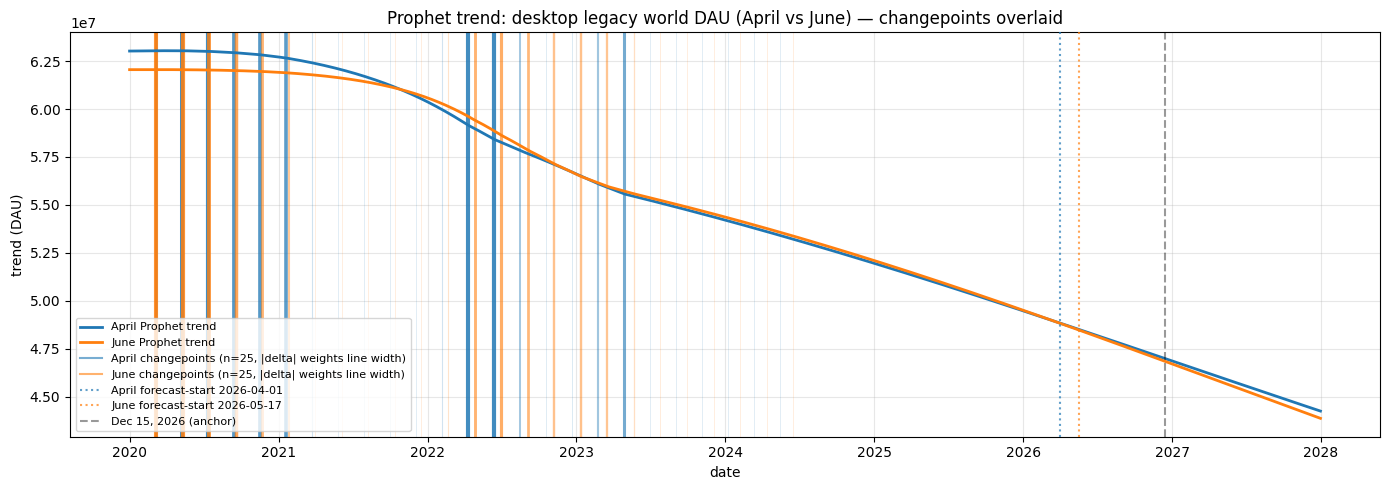


April trend @ 2026-12-15:     46,982,768
June  trend @ 2026-12-15:     46,836,840
Trend gap (June − April): -145,928

April top 5 changepoints by |delta|:
      date  delta
2022-06-13      2
2020-07-11     -2
2022-04-10      2
2020-05-08     -2
2020-09-12     -2

June  top 5 changepoints by |delta|:
      date  delta
2020-05-10     -3
2020-03-06     -3
2020-07-14     -3
2020-09-17     -2
2022-07-01      2


In [6]:
# [plot-trend]
# Prophet trends overlaid, with each model's changepoints marked.
#
# Each Prophet fit has n_changepoints=25 distributed across the first
# changepoint_range=0.7 of the training history. Many of those have very small
# |delta| (no actual trend change). We mark each changepoint as a vertical line
# whose alpha and line-width scale with |delta| relative to that model's max,
# so visually-prominent ticks are the ones that actually moved the trend.

import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

apr_trend_full = apr_pred_by_date["trend"]
jun_trend_full = jun_pred_by_date["trend"]

ax.plot(apr_trend_full.index, apr_trend_full.values, color="tab:blue", lw=2, label="April Prophet trend", zorder=3)
ax.plot(jun_trend_full.index, jun_trend_full.values, color="tab:orange", lw=2, label="June Prophet trend", zorder=3)


def plot_changepoints(ax, prophet_m, color, label):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)  # average across MCMC chains (here just MAP, 1 row)
    abs_deltas = np.abs(deltas)
    max_abs = abs_deltas.max() if abs_deltas.max() > 0 else 1.0
    for ds, d in zip(cps, deltas):
        weight = abs(d) / max_abs                              # 0..1
        alpha = 0.15 + 0.7 * weight                             # 0.15..0.85
        lw = 0.6 + 2.4 * weight                                 # 0.6..3.0
        ax.axvline(ds, color=color, ls="-", alpha=alpha, lw=lw, zorder=2)
    # one dummy line for the legend entry
    ax.axvline(cps.iloc[0], color=color, ls="-", alpha=0.6, lw=1.5,
               label=f"{label} changepoints (n={len(cps)}, |delta| weights line width)")


plot_changepoints(ax, apr_m, "tab:blue", "April")
plot_changepoints(ax, jun_m, "tab:orange", "June")

ax.axvline(apr_mz.forecast_dates[0], color="tab:blue", ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(jun_mz.forecast_dates[0], color="tab:orange", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026 (anchor)", zorder=4)

ax.set_title("Prophet trend: desktop legacy world DAU (April vs June) — changepoints overlaid")
ax.set_ylabel("trend (DAU)")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Trend value at Dec 15 each side
anchor = pd.Timestamp("2026-12-15")
print(f"\nApril trend @ {anchor.date()}: {apr_trend_full.loc[anchor]:>14,.0f}")
print(f"June  trend @ {anchor.date()}: {jun_trend_full.loc[anchor]:>14,.0f}")
print(f"Trend gap (June − April): {(jun_trend_full.loc[anchor] - apr_trend_full.loc[anchor]):+,.0f}")

# Top 5 changepoints by absolute delta for each model — these are the ones that mattered.
def top_changepoints(prophet_m, n=5):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    rows = pd.DataFrame({"date": cps.values, "delta": deltas})
    rows["abs_delta"] = rows["delta"].abs()
    return rows.sort_values("abs_delta", ascending=False).head(n)[["date","delta"]]


print(f"\nApril top 5 changepoints by |delta|:")
print(top_changepoints(apr_m).to_string(index=False))
print(f"\nJune  top 5 changepoints by |delta|:")
print(top_changepoints(jun_m).to_string(index=False))


## Plot 2 — Yearly seasonality

Yearly seasonality is a multiplicative (fractional) modifier on top of trend when
`seasonality_mode='multiplicative'` (which the factory selects when magnitude correlates with
volatility — almost always true for these series). Plotted across one calendar year so the shape
is comparable.


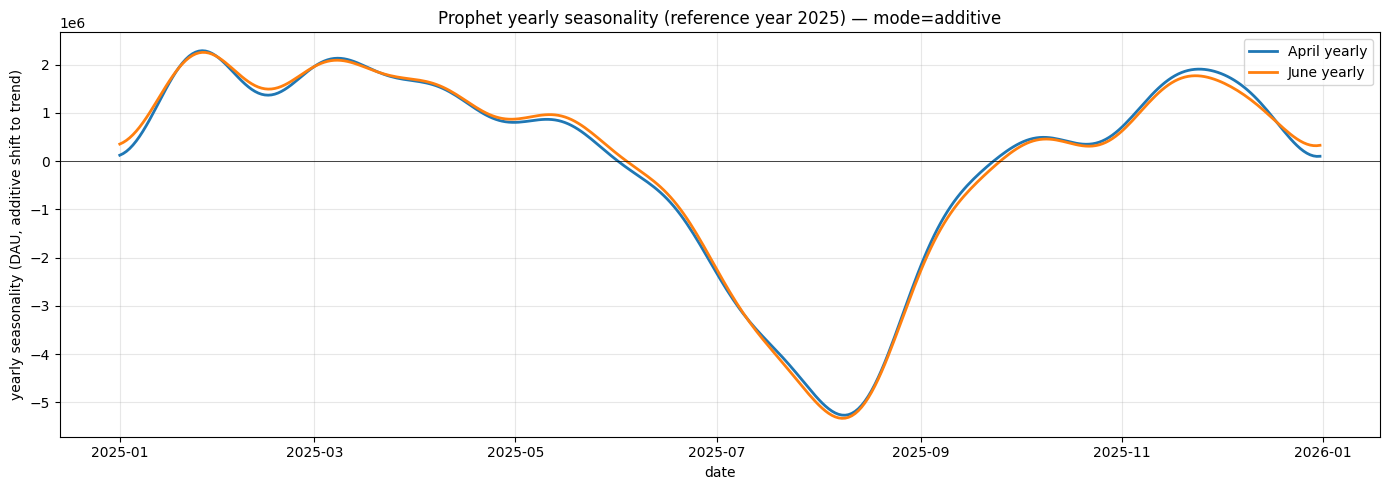


April yearly range over 2025: -5,263,708 DAU  →  +2,287,291 DAU
June  yearly range over 2025: -5,328,760 DAU  →  +2,253,276 DAU

For scale: April mean 2025 trend = 50,728,535 DAU; June = 50,823,297
  April yearly range as % of trend: -10.38% → +4.51%
  June  yearly range as % of trend: -10.48% → +4.43%


In [7]:
# [plot-yearly]
# Plot yearly seasonality over a single representative year for easy shape comparison.
# Use 2025 as the reference year (it falls inside both fits' training history).
#
# Both Mozaic-fit Prophet models use seasonality_mode='additive' (the factory chose
# additive because magnitude/volatility correlation didn't trigger multiplicative).
# So `yearly` is a raw DAU additive offset to trend, not a fractional modifier.

ref_year_start = pd.Timestamp("2025-01-01")
ref_year_end   = pd.Timestamp("2025-12-31")

apr_yearly = apr_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]
jun_yearly = jun_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]

mode_apr = apr_m.seasonality_mode
mode_jun = jun_m.seasonality_mode
assert mode_apr == mode_jun, f"Mode mismatch: April={mode_apr}, June={mode_jun}"

fig, ax = plt.subplots(figsize=(14, 5))
if mode_apr == "additive":
    ax.plot(apr_yearly.index, apr_yearly.values, color="tab:blue", lw=2, label="April yearly")
    ax.plot(jun_yearly.index, jun_yearly.values, color="tab:orange", lw=2, label="June yearly")
    ax.set_ylabel("yearly seasonality (DAU, additive shift to trend)")
    fmt = "{:>+,.0f} DAU"
else:
    ax.plot(apr_yearly.index, apr_yearly.values * 100, color="tab:blue", lw=2, label="April yearly")
    ax.plot(jun_yearly.index, jun_yearly.values * 100, color="tab:orange", lw=2, label="June yearly")
    ax.set_ylabel("yearly seasonality (% of trend, multiplicative)")
    fmt = "{:>+.2f}%"
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Prophet yearly seasonality (reference year 2025) — mode={mode_apr}")
ax.set_xlabel("date")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if mode_apr == "additive":
    print(f"\nApril yearly range over 2025: {apr_yearly.min():>+,.0f} DAU  →  {apr_yearly.max():>+,.0f} DAU")
    print(f"June  yearly range over 2025: {jun_yearly.min():>+,.0f} DAU  →  {jun_yearly.max():>+,.0f} DAU")
    # As percent of mean trend over the same window
    apr_trend_mean = apr_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
    jun_trend_mean = jun_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
    print(f"\nFor scale: April mean 2025 trend = {apr_trend_mean:,.0f} DAU; June = {jun_trend_mean:,.0f}")
    print(f"  April yearly range as % of trend: {apr_yearly.min()/apr_trend_mean*100:+.2f}% → {apr_yearly.max()/apr_trend_mean*100:+.2f}%")
    print(f"  June  yearly range as % of trend: {jun_yearly.min()/jun_trend_mean*100:+.2f}% → {jun_yearly.max()/jun_trend_mean*100:+.2f}%")
else:
    print(f"\nApril yearly range over 2025: {apr_yearly.min()*100:+.2f}%  →  {apr_yearly.max()*100:+.2f}%")
    print(f"June  yearly range over 2025: {jun_yearly.min()*100:+.2f}%  →  {jun_yearly.max()*100:+.2f}%")


## Plot 3 — Weekly seasonality

The factory adds two conditional weekly seasonalities:
- `weekly_historical` — active for training data **before** the recent window
- `weekly_recent` — active for the recent window and the forecast horizon

Only `weekly_recent` drives the forecast, so it's the one to compare. Plotted over 14 days so
both weeks are visible.


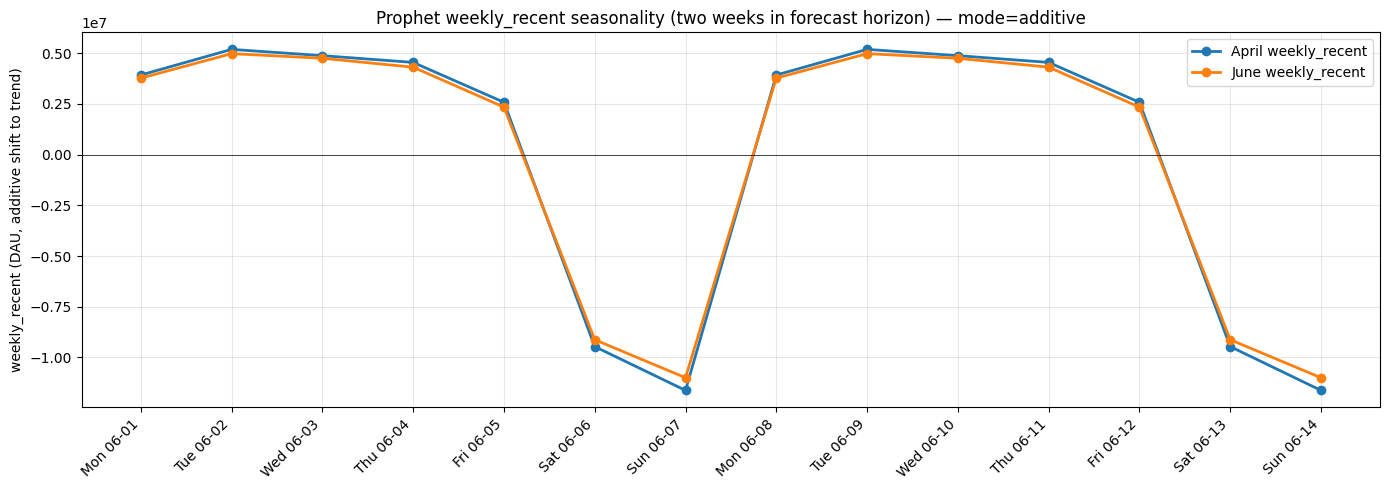


April weekly_recent amplitude (max−min over 7d): +16,800,990 DAU
June  weekly_recent amplitude (max−min over 7d): +15,968,428 DAU

For scale (trend over plot window):
  April: 48,353,565 DAU; weekly amplitude as % of trend: 34.75%
  June:  48,311,679 DAU; weekly amplitude as % of trend: 33.05%


In [8]:
# [plot-weekly]
# weekly_recent is the active seasonality for the forecast horizon. Plot two weeks of it.
# Both models should have a `weekly_recent` column. Additive mode means values are in DAU.

# Anchor: a Monday in the forecast horizon where both models have weekly_recent active.
week_start = pd.Timestamp("2026-06-01")  # Monday in forecast horizon
two_weeks_end = week_start + pd.Timedelta(days=13)

apr_weekly = apr_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]
jun_weekly = jun_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]

mode_apr = apr_m.seasonality_mode
mode_jun = jun_m.seasonality_mode
assert mode_apr == mode_jun, f"Mode mismatch: April={mode_apr}, June={mode_jun}"

fig, ax = plt.subplots(figsize=(14, 5))
day_labels = [(week_start + pd.Timedelta(days=i)).strftime("%a %m-%d") for i in range(len(apr_weekly))]
if mode_apr == "additive":
    ax.plot(range(len(apr_weekly)), apr_weekly.values, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
    ax.plot(range(len(jun_weekly)), jun_weekly.values, color="tab:orange", marker="o", lw=2, label="June weekly_recent")
    ax.set_ylabel("weekly_recent (DAU, additive shift to trend)")
else:
    ax.plot(range(len(apr_weekly)), apr_weekly.values * 100, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
    ax.plot(range(len(jun_weekly)), jun_weekly.values * 100, color="tab:orange", marker="o", lw=2, label="June weekly_recent")
    ax.set_ylabel("weekly_recent (% of trend, multiplicative)")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(len(apr_weekly)))
ax.set_xticklabels(day_labels, rotation=45, ha="right")
ax.set_title(f"Prophet weekly_recent seasonality (two weeks in forecast horizon) — mode={mode_apr}")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Day-of-week amplitude over the first 7 days
apr_amp = apr_weekly.iloc[:7].max() - apr_weekly.iloc[:7].min()
jun_amp = jun_weekly.iloc[:7].max() - jun_weekly.iloc[:7].min()
if mode_apr == "additive":
    print(f"\nApril weekly_recent amplitude (max−min over 7d): {apr_amp:>+,.0f} DAU")
    print(f"June  weekly_recent amplitude (max−min over 7d): {jun_amp:>+,.0f} DAU")
    apr_trend_mean = apr_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
    jun_trend_mean = jun_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
    print(f"\nFor scale (trend over plot window):")
    print(f"  April: {apr_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {apr_amp/apr_trend_mean*100:.2f}%")
    print(f"  June:  {jun_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {jun_amp/jun_trend_mean*100:.2f}%")
else:
    print(f"\nApril weekly_recent amplitude (max−min over 7d): {apr_amp*100:.2f}%")
    print(f"June  weekly_recent amplitude (max−min over 7d): {jun_amp*100:.2f}%")


## Pinning June's changepoints to April's dates

We re-fit a third Prophet model on June's data, but force the changepoint dates to be exactly
the 25 dates Prophet chose for the April fit. Prophet's constructor accepts an explicit
`changepoints=[...]` argument that overrides the auto-generated grid; `n_changepoints` and
`changepoint_range` are ignored when this is set.

Both fits then share the same set of potential changepoint dates. The per-changepoint deltas
(slope adjustments) are still re-fit from June's data — so this isolates the effect of *where*
Prophet allows trend breaks, holding the rest of the model constant.

The 2026-focused trend chart that follows overlays April's trend, the pinned-June trend, both
models' forecasts (yhat), and the observed 2026 training-period DAU.


In [9]:
# [pin-june-to-april-changepoints]
# Fit a third Prophet model: June data + April's changepoint dates.
#
# Prophet's constructor accepts `changepoints=[...]` as an explicit override of the
# auto-generated grid. When set, `n_changepoints` and `changepoint_range` are ignored
# and Prophet places potential changepoints at exactly the given dates. The deltas
# (per-changepoint trend slope adjustments) are re-fit from the June data.
#
# We replicate the factory's logic (logistic growth, cap/floor, conditional weekly
# seasonalities, seed) but swap the changepoint configuration.

import prophet

apr_changepoint_dates = apr_m.changepoints.copy()
print(f"April changepoints to pin onto June fit: {len(apr_changepoint_dates)}")
print(f"  range: {apr_changepoint_dates.min().date()} → {apr_changepoint_dates.max().date()}")
print(f"  all within June training history? {(apr_changepoint_dates <= jun_mz.historical_dates.max()).all()}")

def refit_june_with_pinned_changepoints(mz, changepoint_dates, cps_prior_scale):
    """Reproduce the factory's Prophet setup but use explicit changepoint dates."""
    historical_data = mz.holiday_detrended_historical_data
    historical_dates = mz.historical_dates
    forecast_dates = mz.forecast_dates

    # Logistic-growth branch (matches the factory's path for these series).
    params = dict(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=True,
        uncertainty_samples=1000,
        seasonality_prior_scale=0.00825,
        changepoint_prior_scale=cps_prior_scale,
        growth="logistic",
        seasonality_mode="additive",       # additive selected by factory's correlation check
        changepoints=list(changepoint_dates),  # PIN to April's dates
    )

    historical_mask = historical_dates < forecast_dates[0]
    observed = (
        pd.DataFrame({"ds": historical_dates[historical_mask],
                      "y": historical_data[historical_mask]})
        .dropna().reset_index(drop=True).copy(deep=True)
    )
    future = pd.DataFrame({"ds": forecast_dates})

    cap = observed["y"].tail(366).max() * 1.05
    floor = observed["y"].tail(366).min() * (1.0 if cap > 100e6 else 0.92)
    observed["cap"] = cap; observed["floor"] = floor
    future["cap"] = cap;  future["floor"] = floor

    np.random.seed(42)
    m = prophet.Prophet(**params)

    # Conditional weekly seasonalities (replicates _add_conditional_weekly_seasonality).
    recent_cutoff = forecast_dates[0] - pd.Timedelta(weeks=13)
    if observed["ds"].min() >= recent_cutoff:
        observed["is_historical"] = False
        observed["is_recent"] = True
        future["is_historical"] = False
        future["is_recent"] = True
        m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")
    else:
        observed["is_historical"] = observed["ds"] < recent_cutoff
        observed["is_recent"] = observed["ds"] >= recent_cutoff
        future["is_historical"] = False
        future["is_recent"] = True
        m.add_seasonality(name="weekly_historical", period=7, fourier_order=3, condition_name="is_historical")
        m.add_seasonality(name="weekly_recent", period=7, fourier_order=3, condition_name="is_recent")

    m.fit(observed)
    return m, future


# June used the same changepoint_prior_scale as April (0.15983), per parameters.json.
jun_cps_prior = JUNE_PARAMS["changepoint_prior_scale"]
print(f"Fitting June with April's changepoint dates (cps_prior_scale={jun_cps_prior}) ...")
jun_pinned_m, jun_pinned_future = refit_june_with_pinned_changepoints(
    jun_mz, apr_changepoint_dates, jun_cps_prior
)

# Predict over the same window as the original fits.
jun_pinned_full_future = build_full_future(jun_mz, jun_pinned_m)
jun_pinned_pred = jun_pinned_m.predict(jun_pinned_full_future)
jun_pinned_pred_by_date = jun_pinned_pred.set_index("ds")
print("Done. Predictions ready.")
print()
print(f"Sanity: pinned-June has {len(jun_pinned_m.changepoints)} changepoints; "
      f"dates match April: {list(jun_pinned_m.changepoints) == list(apr_changepoint_dates)}")


April changepoints to pin onto June fit: 25
  range: 2020-03-05 → 2024-05-15
  all within June training history? True
Fitting June with April's changepoint dates (cps_prior_scale=0.15983) ...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1418: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1562: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/brendanwells/work/mo

Done. Predictions ready.

Sanity: pinned-June has 25 changepoints; dates match April: True


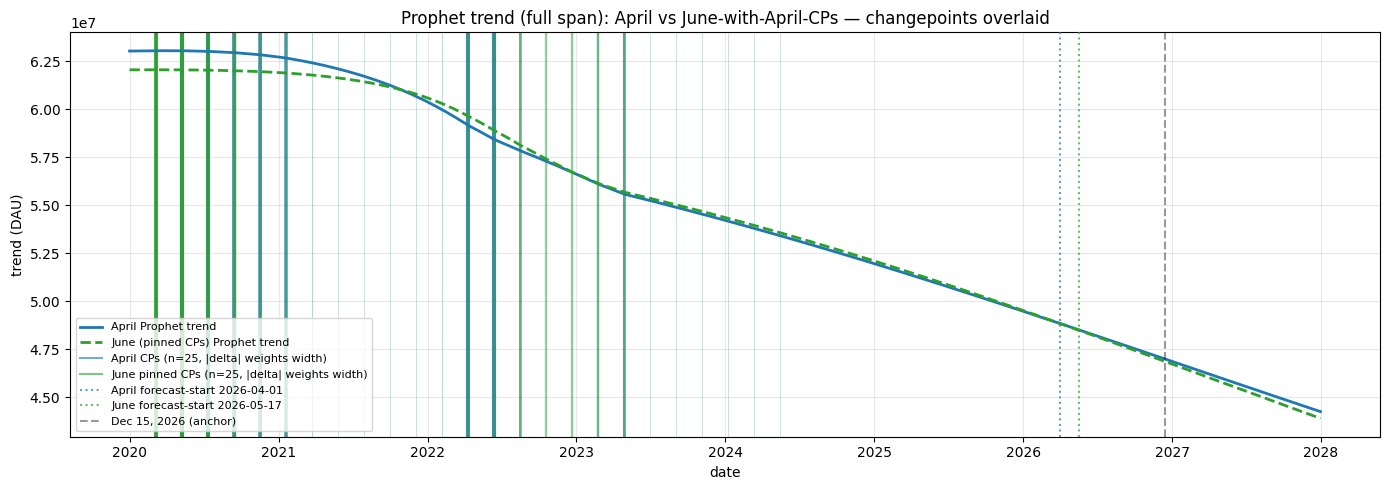


April trend @ 2026-12-15:                   46,982,768
June (pinned CPs) trend @ 2026-12-15:       46,854,242
Trend gap (June pinned − April):            -128,526

April top 5 changepoints by |delta|:
      date  delta
2022-06-13      2
2020-07-11     -2
2022-04-10      2
2020-05-08     -2
2020-09-12     -2

June (pinned to April CPs) top 5 changepoints by |delta|:
      date  delta
2020-05-08     -3
2020-03-05     -3
2020-07-11     -2
2020-09-12     -2
2022-06-13      2


In [10]:
# [plot-trend-pinned-fullspan]
# Full-timeline trend chart for the pinned comparison, analogous to the part-one
# plot-trend cell. The two models share identical changepoint dates by construction,
# so we mark them once (in black) and color the |delta| weights separately for April
# and June-pinned to surface how much each delta moved.

fig, ax = plt.subplots(figsize=(14, 5))

apr_trend_full = apr_pred_by_date["trend"]
jun_pin_trend_full = jun_pinned_pred_by_date["trend"]

ax.plot(apr_trend_full.index, apr_trend_full.values, color="tab:blue", lw=2, label="April Prophet trend", zorder=3)
ax.plot(jun_pin_trend_full.index, jun_pin_trend_full.values, color="tab:green", lw=2, ls="--",
        label="June (pinned CPs) Prophet trend", zorder=3)


def plot_changepoints(ax, prophet_m, color, label):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    abs_deltas = np.abs(deltas)
    max_abs = abs_deltas.max() if abs_deltas.max() > 0 else 1.0
    for ds, d in zip(cps, deltas):
        weight = abs(d) / max_abs
        alpha = 0.15 + 0.7 * weight
        lw = 0.6 + 2.4 * weight
        ax.axvline(ds, color=color, ls="-", alpha=alpha, lw=lw, zorder=2)
    ax.axvline(cps.iloc[0], color=color, ls="-", alpha=0.6, lw=1.5,
               label=f"{label} CPs (n={len(cps)}, |delta| weights width)")


plot_changepoints(ax, apr_m, "tab:blue", "April")
plot_changepoints(ax, jun_pinned_m, "tab:green", "June pinned")

ax.axvline(apr_mz.forecast_dates[0], color="tab:blue",  ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(jun_mz.forecast_dates[0], color="tab:green", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}", zorder=4)
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026 (anchor)", zorder=4)

ax.set_title("Prophet trend (full span): April vs June-with-April-CPs — changepoints overlaid")
ax.set_ylabel("trend (DAU)")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

anchor = pd.Timestamp("2026-12-15")
print(f"\nApril trend @ {anchor.date()}:               {apr_trend_full.loc[anchor]:>14,.0f}")
print(f"June (pinned CPs) trend @ {anchor.date()}:   {jun_pin_trend_full.loc[anchor]:>14,.0f}")
print(f"Trend gap (June pinned − April):            {(jun_pin_trend_full.loc[anchor] - apr_trend_full.loc[anchor]):+,.0f}")


def top_changepoints(prophet_m, n=5):
    cps = prophet_m.changepoints
    deltas = prophet_m.params["delta"].mean(0)
    rows = pd.DataFrame({"date": cps.values, "delta": deltas})
    rows["abs_delta"] = rows["delta"].abs()
    return rows.sort_values("abs_delta", ascending=False).head(n)[["date","delta"]]


print("\nApril top 5 changepoints by |delta|:")
print(top_changepoints(apr_m).to_string(index=False))
print("\nJune (pinned to April CPs) top 5 changepoints by |delta|:")
print(top_changepoints(jun_pinned_m).to_string(index=False))


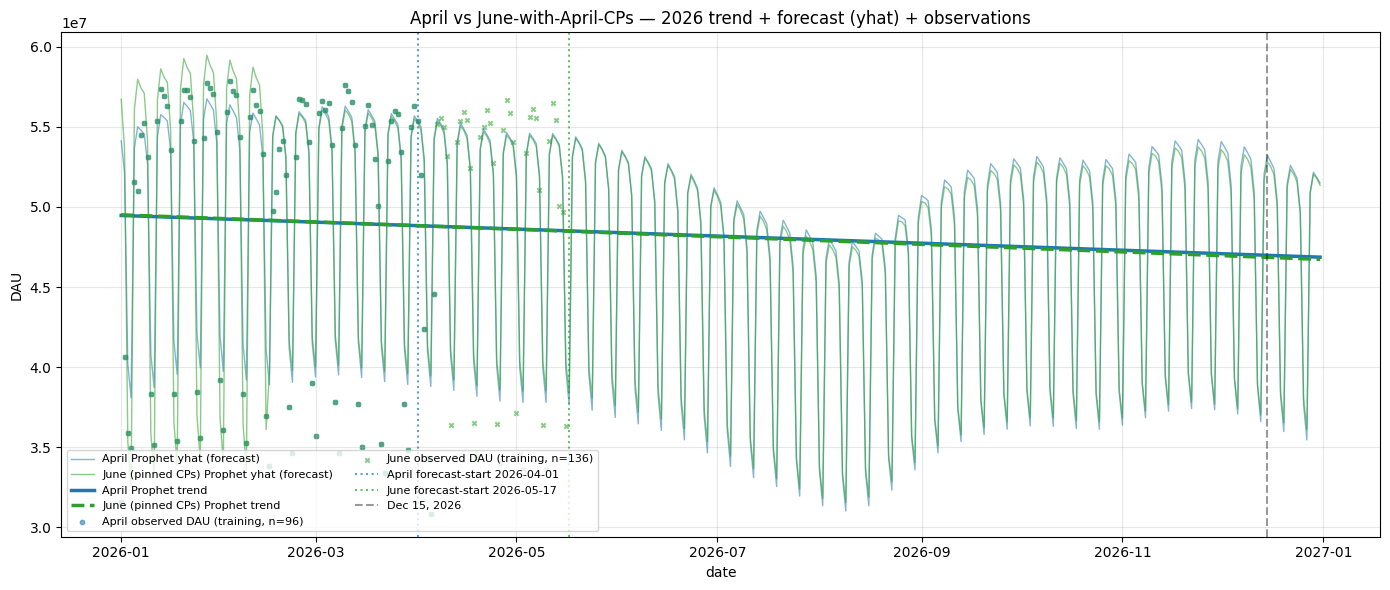


At 2026-12-15:
  April trend:                           46,982,768
  June (pinned CPs) trend:               46,854,242  (vs April: -128,526)
  April yhat (forecast):                 53,231,186
  June (pinned CPs) yhat (forecast):     52,824,664  (vs April: -406,522)


In [11]:
# [plot-trend-pinned-with-forecast]
# 2026-focused chart comparing the April fit to the June fit with April's changepoint
# dates pinned in. Shows:
#   - Trends from both models (bold solid lines).
#   - Full Prophet forecasts (yhat) from both models (thinner lines).
#   - Observed historical DAU for 2026 (scatter, where training data overlaps the window).
# Only the original April changepoint dates are marked, since the pinned June fit by
# construction uses the same set.

ZOOM_START = pd.Timestamp("2026-01-01")
ZOOM_END   = pd.Timestamp("2026-12-31")

apr_trend_z = apr_pred_by_date.loc[ZOOM_START:ZOOM_END, "trend"]
jun_pin_trend_z = jun_pinned_pred_by_date.loc[ZOOM_START:ZOOM_END, "trend"]
apr_yhat_z = apr_pred_by_date.loc[ZOOM_START:ZOOM_END, "yhat"]
jun_pin_yhat_z = jun_pinned_pred_by_date.loc[ZOOM_START:ZOOM_END, "yhat"]

# Observed (training) DAU within the zoom window. Both mz objects store raw historical
# values via `raw_historical_data` (indexed 0..n-1, paired with `historical_dates`).
apr_obs = pd.DataFrame({"ds": list(apr_mz.historical_dates),
                        "y":  list(apr_mz.raw_historical_data)})
jun_obs = pd.DataFrame({"ds": list(jun_mz.historical_dates),
                        "y":  list(jun_mz.raw_historical_data)})
apr_obs_z = apr_obs[(apr_obs["ds"] >= ZOOM_START) & (apr_obs["ds"] <= ZOOM_END)]
jun_obs_z = jun_obs[(jun_obs["ds"] >= ZOOM_START) & (jun_obs["ds"] <= ZOOM_END)]

fig, ax = plt.subplots(figsize=(14, 6))

# Forecast (yhat) curves first (thinner) so the trend lines sit on top.
ax.plot(apr_yhat_z.index, apr_yhat_z.values, color="tab:blue",  lw=1.0, alpha=0.55,
        label="April Prophet yhat (forecast)")
ax.plot(jun_pin_yhat_z.index, jun_pin_yhat_z.values, color="tab:green", lw=1.0, alpha=0.55,
        label="June (pinned CPs) Prophet yhat (forecast)")

# Trend curves bolded.
ax.plot(apr_trend_z.index, apr_trend_z.values, color="tab:blue",  lw=2.5,
        label="April Prophet trend")
ax.plot(jun_pin_trend_z.index, jun_pin_trend_z.values, color="tab:green", lw=2.5, ls="--",
        label="June (pinned CPs) Prophet trend")

# Observed historical DAU for the 2026 window (training-data observations).
ax.scatter(apr_obs_z["ds"], apr_obs_z["y"], color="tab:blue",  s=10, alpha=0.55,
           label=f"April observed DAU (training, n={len(apr_obs_z)})")
ax.scatter(jun_obs_z["ds"], jun_obs_z["y"], color="tab:green", s=10, alpha=0.55, marker="x",
           label=f"June observed DAU (training, n={len(jun_obs_z)})")

# Reference markers.
ax.axvline(apr_mz.forecast_dates[0], color="tab:blue",  ls=":", alpha=0.7, lw=1.5,
           label=f"April forecast-start {apr_mz.forecast_dates[0].date()}")
ax.axvline(jun_mz.forecast_dates[0], color="tab:green", ls=":", alpha=0.7, lw=1.5,
           label=f"June forecast-start {jun_mz.forecast_dates[0].date()}")
ax.axvline(pd.Timestamp("2026-12-15"), color="k", ls="--", alpha=0.4, label="Dec 15, 2026")

# April changepoints (pinned and used by both fits in this plot). Most fall pre-2026 so
# only the latest one or two land inside the zoom window.
for ds in apr_changepoint_dates:
    if ZOOM_START <= ds <= ZOOM_END:
        ax.axvline(ds, color="k", ls="-", alpha=0.15, lw=1.0)

ax.set_title("April vs June-with-April-CPs — 2026 trend + forecast (yhat) + observations")
ax.set_ylabel("DAU")
ax.set_xlabel("date")
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Numerics
anchor = pd.Timestamp("2026-12-15")
print(f"\nAt {anchor.date()}:")
print(f"  April trend:                       {apr_trend_z.loc[anchor]:>14,.0f}")
print(f"  June (pinned CPs) trend:           {jun_pin_trend_z.loc[anchor]:>14,.0f}  "
      f"(vs April: {jun_pin_trend_z.loc[anchor]-apr_trend_z.loc[anchor]:+,.0f})")
print(f"  April yhat (forecast):             {apr_yhat_z.loc[anchor]:>14,.0f}")
print(f"  June (pinned CPs) yhat (forecast): {jun_pin_yhat_z.loc[anchor]:>14,.0f}  "
      f"(vs April: {jun_pin_yhat_z.loc[anchor]-apr_yhat_z.loc[anchor]:+,.0f})")


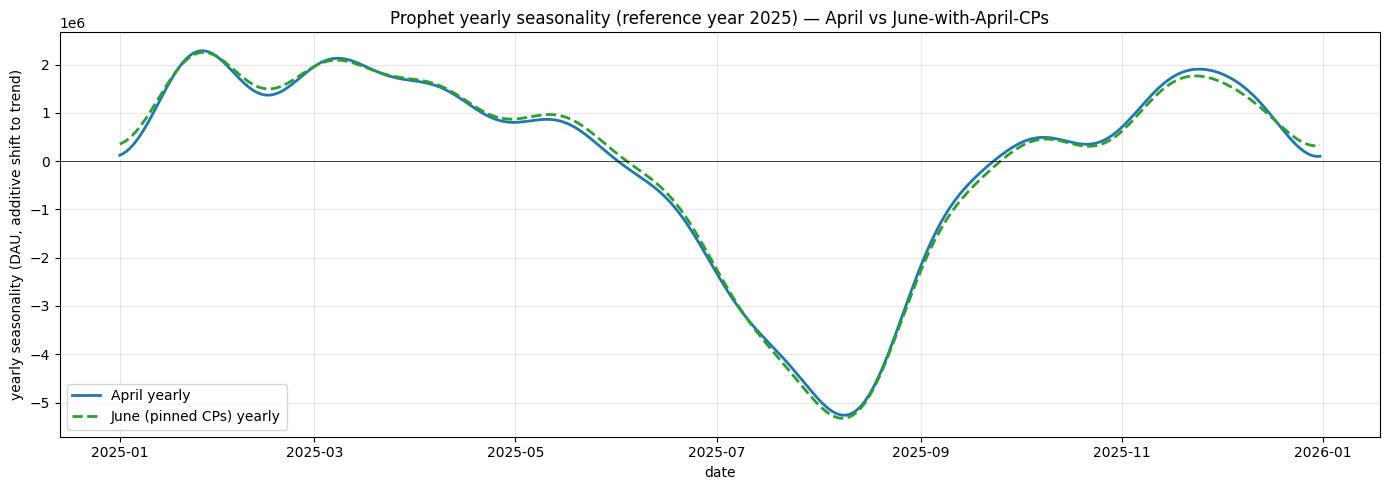


April yearly range over 2025: -5,263,708 DAU  →  +2,287,291 DAU
June (pinned CPs) yearly:     -5,328,067 DAU  →  +2,252,867 DAU

For scale: April mean 2025 trend = 50,728,535 DAU; June pinned = 50,824,387
  April yearly range as % of trend:           -10.38% → +4.51%
  June (pinned) yearly range as % of trend:   -10.48% → +4.43%


In [12]:
# [plot-yearly-pinned]
# Yearly seasonality: April vs June (changepoints pinned to April's dates).
# Both models use additive mode, so values are raw DAU offsets from trend.

ref_year_start = pd.Timestamp("2025-01-01")
ref_year_end   = pd.Timestamp("2025-12-31")

apr_yearly = apr_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]
jun_pin_yearly = jun_pinned_pred_by_date.loc[ref_year_start:ref_year_end, "yearly"]

mode_apr = apr_m.seasonality_mode
mode_pin = jun_pinned_m.seasonality_mode
assert mode_apr == mode_pin == "additive", \
    f"Expected additive mode for both; got April={mode_apr}, June-pinned={mode_pin}"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(apr_yearly.index, apr_yearly.values, color="tab:blue", lw=2, label="April yearly")
ax.plot(jun_pin_yearly.index, jun_pin_yearly.values, color="tab:green", lw=2, ls="--",
        label="June (pinned CPs) yearly")
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Prophet yearly seasonality (reference year 2025) — April vs June-with-April-CPs")
ax.set_ylabel("yearly seasonality (DAU, additive shift to trend)")
ax.set_xlabel("date")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nApril yearly range over 2025: {apr_yearly.min():>+,.0f} DAU  →  {apr_yearly.max():>+,.0f} DAU")
print(f"June (pinned CPs) yearly:     {jun_pin_yearly.min():>+,.0f} DAU  →  {jun_pin_yearly.max():>+,.0f} DAU")
apr_trend_mean = apr_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
jun_pin_trend_mean = jun_pinned_pred_by_date.loc[ref_year_start:ref_year_end, "trend"].mean()
print(f"\nFor scale: April mean 2025 trend = {apr_trend_mean:,.0f} DAU; June pinned = {jun_pin_trend_mean:,.0f}")
print(f"  April yearly range as % of trend:           {apr_yearly.min()/apr_trend_mean*100:+.2f}% → {apr_yearly.max()/apr_trend_mean*100:+.2f}%")
print(f"  June (pinned) yearly range as % of trend:   {jun_pin_yearly.min()/jun_pin_trend_mean*100:+.2f}% → {jun_pin_yearly.max()/jun_pin_trend_mean*100:+.2f}%")


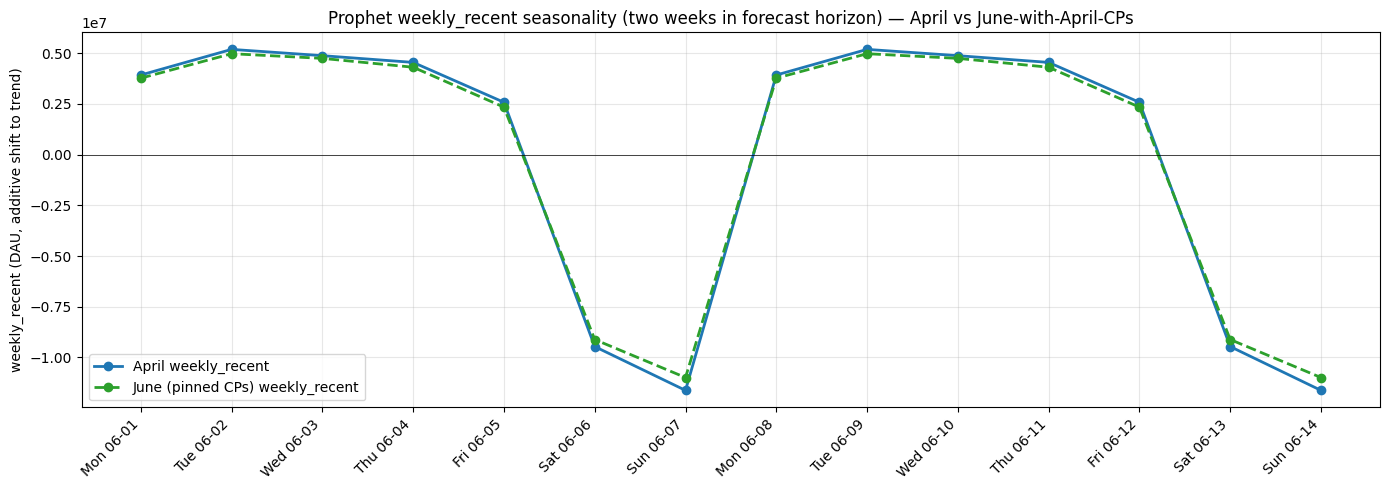


April weekly_recent amplitude (max−min over 7d):           +16,800,990 DAU
June (pinned CPs) weekly_recent amplitude (max−min over 7d): +15,954,986 DAU

For scale (trend over plot window):
  April:               48,353,565 DAU; weekly amplitude as % of trend: 34.75%
  June (pinned CPs):   48,323,013 DAU; weekly amplitude as % of trend: 33.02%


In [13]:
# [plot-weekly-pinned]
# Weekly_recent seasonality: April vs June (changepoints pinned to April's dates).
# Additive mode → values are raw DAU offsets from trend.

week_start = pd.Timestamp("2026-06-01")  # Monday in forecast horizon
two_weeks_end = week_start + pd.Timedelta(days=13)

apr_weekly = apr_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]
jun_pin_weekly = jun_pinned_pred_by_date.loc[week_start:two_weeks_end, "weekly_recent"]

fig, ax = plt.subplots(figsize=(14, 5))
day_labels = [(week_start + pd.Timedelta(days=i)).strftime("%a %m-%d") for i in range(len(apr_weekly))]
ax.plot(range(len(apr_weekly)), apr_weekly.values, color="tab:blue", marker="o", lw=2, label="April weekly_recent")
ax.plot(range(len(jun_pin_weekly)), jun_pin_weekly.values, color="tab:green", marker="o", lw=2, ls="--",
        label="June (pinned CPs) weekly_recent")
ax.axhline(0, color="k", lw=0.5)
ax.set_xticks(range(len(apr_weekly)))
ax.set_xticklabels(day_labels, rotation=45, ha="right")
ax.set_title("Prophet weekly_recent seasonality (two weeks in forecast horizon) — April vs June-with-April-CPs")
ax.set_ylabel("weekly_recent (DAU, additive shift to trend)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

apr_amp = apr_weekly.iloc[:7].max() - apr_weekly.iloc[:7].min()
pin_amp = jun_pin_weekly.iloc[:7].max() - jun_pin_weekly.iloc[:7].min()
print(f"\nApril weekly_recent amplitude (max−min over 7d):           {apr_amp:>+,.0f} DAU")
print(f"June (pinned CPs) weekly_recent amplitude (max−min over 7d): {pin_amp:>+,.0f} DAU")

apr_trend_mean = apr_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
pin_trend_mean = jun_pinned_pred_by_date.loc[week_start:two_weeks_end, "trend"].mean()
print(f"\nFor scale (trend over plot window):")
print(f"  April:               {apr_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {apr_amp/apr_trend_mean*100:.2f}%")
print(f"  June (pinned CPs):   {pin_trend_mean:,.0f} DAU; weekly amplitude as % of trend: {pin_amp/pin_trend_mean*100:.2f}%")


Identity check: yhat gap == trend gap + yearly gap + weekly_recent gap + weekly_historical gap
  max |sum_check − yhat gap| over horizon: 0.000000
  mean |sum_check − yhat gap|:             0.000000
(If those are ~0 the decomposition is exact and any narrative based on it is rigorous.)

=== Component breakdown of (April − June_pinned) at 2026-12-15 ===
                        April  June_pinned  Gap (Apr−Pin)
trend             +46,982,768  +46,854,242       +128,526
yearly             +1,067,864   +1,003,035        +64,829
weekly_recent      +5,180,554   +4,967,388       +213,166
weekly_historical          +0           +0             +0
yhat              +53,231,186  +52,824,664       +406,522

Trend gap            : +128,526  ( +31.6% of yhat gap)
Seasonality gap (sum): +277,996  ( +68.4% of yhat gap)
Yhat gap (total)     : +406,522

=== Per-component RMS contribution to the yhat gap (over full forecast horizon) ===
  trend               : RMS =    203,278   mean |gap| =    179,003   

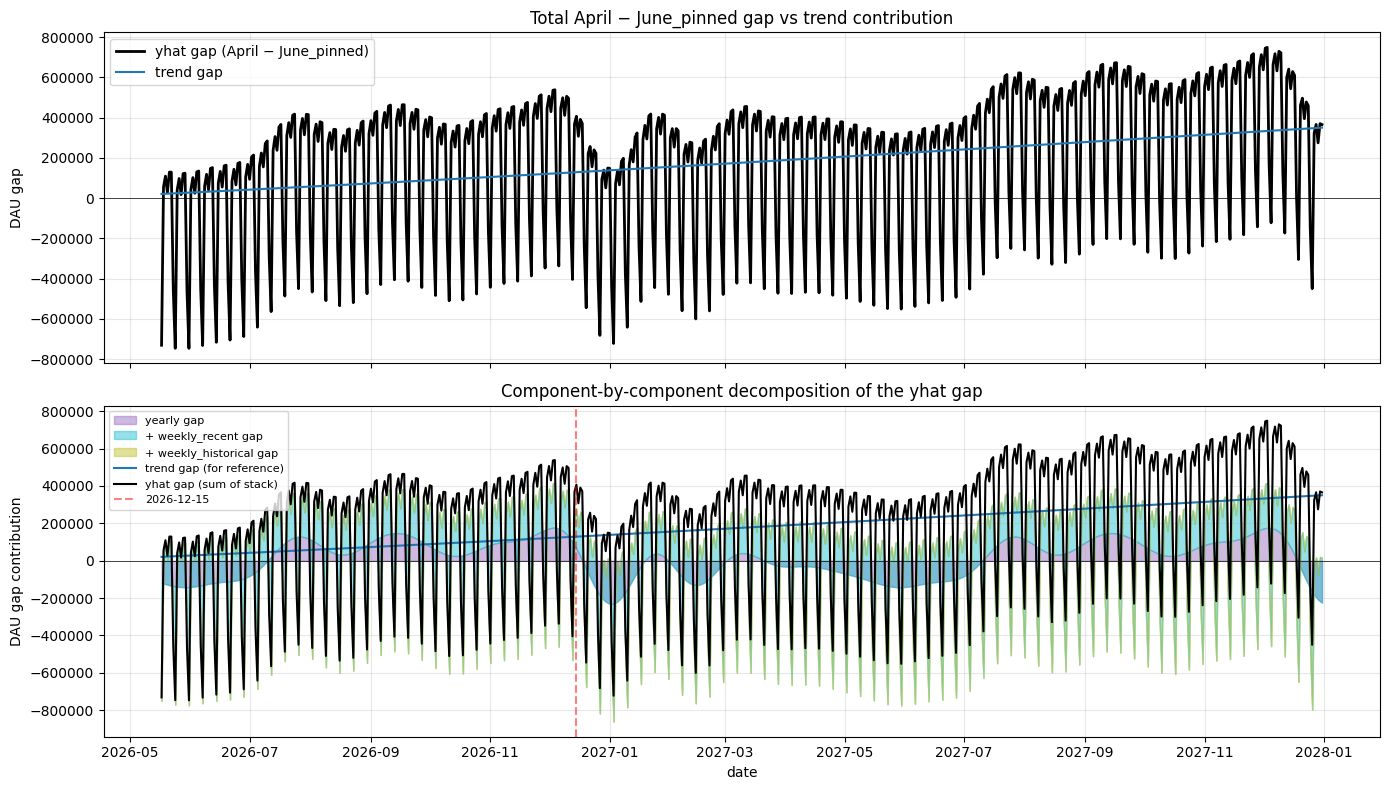

In [14]:
# [prove-seasonality-driver]
# Decompose the April-vs-June_pinned yhat gap into its additive components.
#
# Both Prophet models use additive seasonality_mode, no Prophet-level holidays added
# (Mozaic handles holiday detrending externally). So at every date:
#
#     yhat = trend + yearly + weekly_recent + weekly_historical
#
# (weekly_historical is zero in the forecast horizon by construction).
#
# Therefore the per-date gap decomposes exactly:
#
#     gap_yhat(d)   = (apr_yhat   - jun_pin_yhat)(d)
#                   = gap_trend(d) + gap_yearly(d) + gap_weekly_recent(d) + gap_weekly_historical(d)
#
# We compute each piece over the forecast horizon and plot how much each contributes
# to the overall yhat gap. If trend gap dwarfs seasonality gaps -> trend is the driver.
# If seasonality gaps dwarf trend gap -> seasonality is the driver.

FORECAST_START = max(apr_mz.forecast_dates[0], jun_mz.forecast_dates[0])
FORECAST_END   = pd.Timestamp("2027-12-31")
horizon = pd.date_range(FORECAST_START, FORECAST_END, freq="D")

components = ["trend", "yearly", "weekly_recent", "weekly_historical", "yhat"]
apr_comp = apr_pred_by_date.loc[horizon, components].copy()
pin_comp = jun_pinned_pred_by_date.loc[horizon, components].copy()

gap = (apr_comp - pin_comp).copy()  # April − June_pinned, per component, per date
gap["sum_check"] = gap["trend"] + gap["yearly"] + gap["weekly_recent"] + gap["weekly_historical"]
gap["sum_minus_yhat"] = gap["sum_check"] - gap["yhat"]

print("Identity check: yhat gap == trend gap + yearly gap + weekly_recent gap + weekly_historical gap")
print(f"  max |sum_check − yhat gap| over horizon: {gap['sum_minus_yhat'].abs().max():.6f}")
print(f"  mean |sum_check − yhat gap|:             {gap['sum_minus_yhat'].abs().mean():.6f}")
print("(If those are ~0 the decomposition is exact and any narrative based on it is rigorous.)")
print()

# Numeric table at the Dec 15 anchor.
anchor = pd.Timestamp("2026-12-15")
print(f"=== Component breakdown of (April − June_pinned) at {anchor.date()} ===")
table = pd.DataFrame({
    "April":          apr_comp.loc[anchor],
    "June_pinned":    pin_comp.loc[anchor],
    "Gap (Apr−Pin)":  apr_comp.loc[anchor] - pin_comp.loc[anchor],
})
print(table.to_string(float_format=lambda x: f"{x:>+,.0f}"))
print()
trend_gap_anchor = gap.loc[anchor, "trend"]
seas_gap_anchor = gap.loc[anchor, "yearly"] + gap.loc[anchor, "weekly_recent"] + gap.loc[anchor, "weekly_historical"]
yhat_gap_anchor = gap.loc[anchor, "yhat"]
print(f"Trend gap            : {trend_gap_anchor:>+,.0f}  ({trend_gap_anchor/yhat_gap_anchor*100:>+6.1f}% of yhat gap)")
print(f"Seasonality gap (sum): {seas_gap_anchor:>+,.0f}  ({seas_gap_anchor/yhat_gap_anchor*100:>+6.1f}% of yhat gap)")
print(f"Yhat gap (total)     : {yhat_gap_anchor:>+,.0f}")

# Per-component contribution to *the gap* averaged over the whole forecast horizon.
# "% of |yhat gap|" using mean |gap_yhat| as the denominator gives an apples-to-apples
# size for each component's contribution, sign-agnostic.
mean_abs_yhat_gap = gap["yhat"].abs().mean()
print()
print("=== Per-component RMS contribution to the yhat gap (over full forecast horizon) ===")
for comp in ["trend","yearly","weekly_recent","weekly_historical"]:
    rms = (gap[comp] ** 2).mean() ** 0.5
    mean_abs = gap[comp].abs().mean()
    print(f"  {comp:20s}: RMS = {rms:>10,.0f}   mean |gap| = {mean_abs:>10,.0f}   "
          f"({mean_abs/mean_abs_yhat_gap*100:>5.1f}% of mean |yhat gap|)")

# Plot: each component's signed contribution to (Apr − Pin) over the forecast horizon.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(gap.index, gap["yhat"], color="black", lw=2.0, label="yhat gap (April − June_pinned)")
axes[0].plot(gap.index, gap["trend"], color="tab:blue", lw=1.5, label="trend gap")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_title("Total April − June_pinned gap vs trend contribution")
axes[0].set_ylabel("DAU gap")
axes[0].legend(loc="best")
axes[0].grid(alpha=0.3)

# Stacked area for the seasonality components, with trend as a line for reference.
axes[1].fill_between(gap.index, 0, gap["yearly"], color="tab:purple", alpha=0.45, label="yearly gap")
axes[1].fill_between(gap.index, gap["yearly"], gap["yearly"] + gap["weekly_recent"], color="tab:cyan",
                     alpha=0.45, label="+ weekly_recent gap")
axes[1].fill_between(gap.index, gap["yearly"] + gap["weekly_recent"],
                     gap["yearly"] + gap["weekly_recent"] + gap["weekly_historical"],
                     color="tab:olive", alpha=0.45, label="+ weekly_historical gap")
axes[1].plot(gap.index, gap["trend"], color="tab:blue", lw=1.5, label="trend gap (for reference)")
axes[1].plot(gap.index, gap["yhat"], color="black", lw=1.5, label="yhat gap (sum of stack)")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axvline(anchor, color="r", ls="--", alpha=0.5, label=f"{anchor.date()}")
axes[1].set_title("Component-by-component decomposition of the yhat gap")
axes[1].set_ylabel("DAU gap contribution")
axes[1].set_xlabel("date")
axes[1].legend(loc="best", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Notes

- Trend is the load-bearing component for the Dec-15 gap (see `june_vs_april_desktop_diagnostic.ipynb`).
- Yearly seasonality is a smooth periodic modifier; differences here would indicate Prophet detected
  a different annual cycle (unlikely on a few weeks of new data).
- Weekly_recent reflects the weekly seasonality during the recent window; differences could matter
  if the recent window slope itself has changed weekly pattern.
- The cross-check cell above proves the re-fit reproduces the saved `.trend` exactly; the same
  underlying Prophet model is responsible for all three plotted components.
